# Channel-Level Early Fusion of Handcrafted and Deep Features for Cotton Disease Classification
### Swin Transformer with HOG / Wavelet Spatial Maps as Extra Input Channels

**Research question.** Does injecting handcrafted spatial descriptors (HOG, wavelet) directly
into Swin-Tiny's patch-embedding layer — as additional image channels, not as vectors
concatenated after the backbone runs — improve cotton leaf disease classification over a
Swin-only baseline?

**Why this is architecturally different from late/feature-level fusion.** A prior
experiment in this project fused HOG/SIFT/Wavelet as flattened PCA vectors, concatenated
with Swin's 768-d output *after* Swin had already processed the raw RGB image independently
(late fusion). That is the majority approach in the plant-disease literature (e.g. Liu et
al., *Leaf image based plant disease identification using transfer learning and feature
fusion*, 2022; the tomato ABCD-rule + CNN fusion system in *Synergistic use of handcrafted
and deep learning features*, Sci. Rep. 2024). This notebook instead implements **early
fusion**: HOG and wavelet are computed as spatial maps (same height/width as the image, one
channel each) and stacked directly with RGB *before* the image ever reaches Swin's
patch-embedding convolution. Swin's own weights process the handcrafted signal as part of
its normal forward pass — literally "features as input to the model," not features added to
the model's output.

**Precedent for this specific design.**
- *WaveletFusion* (Kumar & Singh, 2025, ScienceDirect) — channel-wise concatenation of
  wavelet sub-bands with the grayscale image, feeding a ResNet-18 encoder, for plant leaf
  disease classification. Directly analogous to the wavelet-channel design used here.
- *Hybrid Channel Based Pedestrian Detection* (Cao et al., arXiv:1912.12431) — HOG+LUV
  handcrafted channels stacked alongside CNN feature channels; ablations there show
  handcrafted channels can match or exceed CNN-only channels on small/fine-grained detail.
- *Isolated Channel Vision Transformers* (2025) — addresses exactly the patch-embedding
  extension problem this notebook solves for Swin: adapting a transformer pretrained on a
  fixed channel count to accept additional channels.

**Four models, trained and reported independently, same recipe:**
1. `swin_rgb` — Swin-Tiny, unmodified 3-channel input (baseline)
2. `swin_hog` — Swin-Tiny, 4-channel input (RGB + HOG spatial map)
3. `swin_wavelet` — Swin-Tiny, 4-channel input (RGB + wavelet approximation map)
4. `swin_hog_wavelet` — Swin-Tiny, 5-channel input (RGB + HOG map + wavelet map)

**Fixed experimental controls (so any accuracy difference reflects the architecture, not
the recipe):** identical 30 epochs for every model (no early stopping), identical
AdamW + cosine schedule + label-smoothed class-weighted loss, identical fixed
train/val/test split, identical seed. Full end-to-end fine-tuning (not frozen) for all
four, since the newly-added channels start from averaged, non-pretrained weights and can
only become useful if the backbone is allowed to adapt to them.


## 1. Setup

In [1]:
# Cell 1 — Imports
import os, json, time, random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from skimage.feature import hog as hog_viz_fn
import pywt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import torchvision.datasets as tv_datasets

from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [2]:
# Cell 2 — Configuration
CONFIG = {
    "dataset_root": "/kaggle/input/datasets/engrmuhammadammar/dataset-augmented-roboflow-ver-x/dataset augmented roboflow_ver_x",   
    "train_subdir": "train",
    "val_subdir": "valid",     
    "test_subdir": "test",

    "work_dir": "/kaggle/working",
    "model_dir": "/kaggle/working/models",
    "feature_dir": "/kaggle/working/features",
    "results_csv": "/kaggle/working/early_fusion_results.csv",

    "seed": 42,
    "image_size": 224,
    "expected_class_names": [
        "Fresh_Leaf", "Leaf_Reddening", "Leaf_Spot_Bacterial_Blight",
        "Red_Cotton_Bug", "Yellowish_Leaf",
    ],

    "hog_orientations": 9,
    "hog_pixels_per_cell": (16, 16),
    "hog_cells_per_block": (2, 2),
    "hog_block_norm": "L2-Hys",
    "wavelet_name": "db2",

    "batch_size": 32,
    "num_workers": 2,
    "epochs": 30,                
    #"lr": 3e-5,
    #"weight_decay": 0.05,
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.1,
    "mixed_precision": True,

    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

for d in ["model_dir", "feature_dir"]:
    Path(CONFIG[d]).mkdir(parents=True, exist_ok=True)

print(json.dumps({k: v for k, v in CONFIG.items() if k != "device"}, indent=2))


{
  "dataset_root": "/kaggle/input/datasets/engrmuhammadammar/dataset-augmented-roboflow-ver-x/dataset augmented roboflow_ver_x",
  "train_subdir": "train",
  "val_subdir": "valid",
  "test_subdir": "test",
  "work_dir": "/kaggle/working",
  "model_dir": "/kaggle/working/models",
  "feature_dir": "/kaggle/working/features",
  "results_csv": "/kaggle/working/early_fusion_results.csv",
  "seed": 42,
  "image_size": 224,
  "expected_class_names": [
    "Fresh_Leaf",
    "Leaf_Reddening",
    "Leaf_Spot_Bacterial_Blight",
    "Red_Cotton_Bug",
    "Yellowish_Leaf"
  ],
  "hog_orientations": 9,
  "hog_pixels_per_cell": [
    16,
    16
  ],
  "hog_cells_per_block": [
    2,
    2
  ],
  "hog_block_norm": "L2-Hys",
  "wavelet_name": "db2",
  "batch_size": 32,
  "num_workers": 2,
  "epochs": 30,
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "label_smoothing": 0.1,
  "mixed_precision": true
}


In [3]:
# Cell 3 — Reproducibility
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(CONFIG["seed"])


In [4]:
# Cell 4 — GPU detection
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memory (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
print("Torch:", torch.__version__, "| torchvision:", torchvision.__version__)


CUDA available: True
GPU: Tesla T4
Memory (GB): 15.6
Torch: 2.10.0+cu128 | torchvision: 0.25.0+cu128


## 2. Dataset

In [5]:
# Cell 5 — Load existing train/val/test folders directly (fixed holdout, no re-splitting)
def discover_split(root, split_name):
    root = Path(root)
    assert root.exists(), f"Split folder not found: {root}"
    classes = sorted([p.name for p in root.iterdir() if p.is_dir()])
    records = []
    for cls in classes:
        for img_path in (root / cls).rglob("*"):
            if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                records.append({"path": str(img_path), "label": cls})
    return pd.DataFrame(records), classes

train_root = Path(CONFIG["dataset_root"], CONFIG["train_subdir"])
val_root   = Path(CONFIG["dataset_root"], CONFIG["val_subdir"])
test_root  = Path(CONFIG["dataset_root"], CONFIG["test_subdir"])

train_df, classes_train = discover_split(train_root, "train")
val_df,   classes_val   = discover_split(val_root,   "val")
test_df,  classes_test  = discover_split(test_root,  "test")

assert classes_train == classes_val == classes_test
class_names = classes_train
assert class_names == CONFIG["expected_class_names"], f"Class mismatch: {class_names}"
class_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES = len(class_names)

for df in (train_df, val_df, test_df):
    df["label_idx"] = df["label"].map(class_to_idx)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("\nPer-class train counts:")
print(train_df["label"].value_counts())


Train: 3371  Val: 74  Test: 75

Per-class train counts:
label
Leaf_Spot_Bacterial_Blight    1146
Fresh_Leaf                     682
Leaf_Reddening                 552
Red_Cotton_Bug                 536
Yellowish_Leaf                 455
Name: count, dtype: int64


In [6]:
# Cell 6 — Class weights (inverse frequency, computed from the ACTUAL current train split)
train_counts = torch.tensor(
    np.bincount(train_df["label_idx"].values, minlength=NUM_CLASSES), dtype=torch.float32
)
class_weights = (train_counts.sum() / (NUM_CLASSES * train_counts)).to(CONFIG["device"])
print("Class weights:", class_weights.cpu().numpy())


Class weights: [0.98856306 1.2213768  0.58830714 1.2578359  1.4817582 ]


## 3. Preprocessing and channel construction

`preprocess_rgb` handles the base image (resize + RGB), identical for every model.
`extract_hog_map` / `extract_wavelet_map` return **spatial** maps (same H, W as the image) —
not the flattened, PCA-reduced vectors used in the late-fusion notebook. These are what get
stacked as extra channels.


In [7]:
# Cell 7 — Base preprocessing + HOG/wavelet spatial maps
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def preprocess_rgb(path, size=None):
    size = size or CONFIG["image_size"]
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)

def extract_hog_map(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    _, hog_map = hog_viz_fn(
        gray, orientations=CONFIG["hog_orientations"],
        pixels_per_cell=CONFIG["hog_pixels_per_cell"],
        cells_per_block=CONFIG["hog_cells_per_block"],
        block_norm=CONFIG["hog_block_norm"], visualize=True,
    )
    hog_map = hog_map.astype(np.float32)
    hog_map = (hog_map - hog_map.min()) / (hog_map.max() - hog_map.min() + 1e-8)
    return hog_map

def extract_wavelet_map(image_rgb):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY).astype(np.float64)
    cA, _ = pywt.dwt2(gray, CONFIG["wavelet_name"])
    cA = cv2.resize(cA.astype(np.float32), (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_LINEAR)
    cA = (cA - cA.min()) / (cA.max() - cA.min() + 1e-8)
    return cA

rgb_norm = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def build_input_tensor(path, channel_spec):
    """channel_spec: subset of ['rgb','hog','wavelet'], 'rgb' always required and always first."""
    img = preprocess_rgb(path)
    rgb_tensor = rgb_norm(transforms.ToTensor()(img))   # (3, H, W), ImageNet-normalized
    extra = []
    if "hog" in channel_spec:
        h = extract_hog_map(img)
        extra.append(torch.from_numpy((h - 0.5) / 0.5).unsqueeze(0))
    if "wavelet" in channel_spec:
        w = extract_wavelet_map(img)
        extra.append(torch.from_numpy((w - 0.5) / 0.5).unsqueeze(0))
    if extra:
        return torch.cat([rgb_tensor] + extra, dim=0).float()
    return rgb_tensor.float()

# quick sanity check
_sample_path = train_df.iloc[0]["path"]
for spec in [["rgb"], ["rgb", "hog"], ["rgb", "wavelet"], ["rgb", "hog", "wavelet"]]:
    t = build_input_tensor(_sample_path, spec)
    print(spec, "->", tuple(t.shape))


def build_input_tensor_tiled(path, which):
    """Tile a single handcrafted map (HOG or wavelet) into all 3 channels, in place of RGB.
    Keeps Swin's pretrained 3-channel structure fully intact (no weight averaging needed) —
    isolates how much signal the handcrafted map carries entirely on its own, with no color
    or texture information from the original photo at all."""
    img = preprocess_rgb(path)
    if which == "hog":
        m = extract_hog_map(img)
    elif which == "wavelet":
        m = extract_wavelet_map(img)
    else:
        raise ValueError(f"Unknown map: {which}")
    m = torch.from_numpy((m - 0.5) / 0.5).float()
    return m.unsqueeze(0).repeat(3, 1, 1)   # (3, H, W) — same map in all three channels

# sanity check
for which in ["hog", "wavelet"]:
    t = build_input_tensor_tiled(_sample_path, which)
    print(f"tiled({which}) -> {tuple(t.shape)}")


['rgb'] -> (3, 224, 224)
['rgb', 'hog'] -> (4, 224, 224)
['rgb', 'wavelet'] -> (4, 224, 224)
['rgb', 'hog', 'wavelet'] -> (5, 224, 224)
tiled(hog) -> (3, 224, 224)
tiled(wavelet) -> (3, 224, 224)


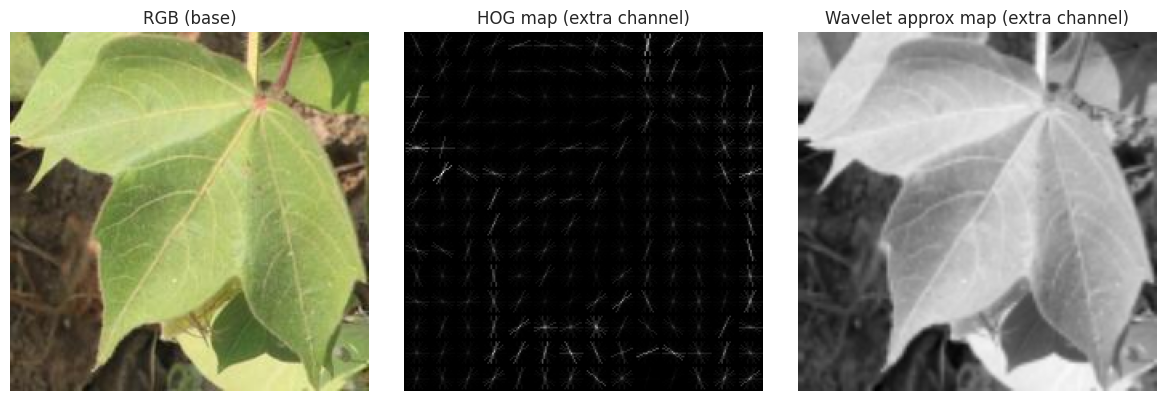

In [8]:
# Cell 8 — Visual check: RGB vs HOG map vs wavelet map for one sample
img = preprocess_rgb(_sample_path)
hog_map = extract_hog_map(img)
wav_map = extract_wavelet_map(img)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img); axes[0].set_title("RGB (base)"); axes[0].axis("off")
axes[1].imshow(hog_map, cmap="gray"); axes[1].set_title("HOG map (extra channel)"); axes[1].axis("off")
axes[2].imshow(wav_map, cmap="gray"); axes[2].set_title("Wavelet approx map (extra channel)"); axes[2].axis("off")
plt.tight_layout(); plt.show()


In [9]:
# Cell 9 — Dataset class parameterized by channel_spec (supports both stacked and tiled modes)
class ChannelDataset(Dataset):
    def __init__(self, df, channel_spec, mode="stack"):
        """mode='stack': channel_spec is a list appended to RGB (e.g. ['hog','wavelet']).
        mode='tile': channel_spec is a single map name ('hog' or 'wavelet'), tiled into
        3 channels with NO rgb present at all."""
        self.paths = df["path"].values
        self.labels = df["label_idx"].values
        self.channel_spec = channel_spec
        self.mode = mode

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        if self.mode == "tile":
            x = build_input_tensor_tiled(self.paths[idx], self.channel_spec)
        else:
            x = build_input_tensor(self.paths[idx], self.channel_spec)
        return x, int(self.labels[idx])


## 4. Model — Swin-Tiny with an extended patch-embedding layer

The extension technique (copy pretrained RGB weights into the first 3 channels, average
them into any additional channels) is the standard method for adapting a pretrained
convolution to more input channels without discarding the ImageNet prior — used in
multispectral remote-sensing fine-tuning and in Isolated Channel ViT's channel-adaptive
patch embedding. Full end-to-end fine-tuning is used for all four models (not frozen),
since the added channels' weights start from an approximation and need real gradient
signal to become useful, unlike the original RGB channels which are already well-trained.


In [10]:
# Cell 10 — Channel-extended Swin-Tiny builder
def build_swin(num_extra_channels, num_classes, pretrained=True):
    weights = torchvision.models.Swin_T_Weights.IMAGENET1K_V1 if pretrained else None
    model = torchvision.models.swin_t(weights=weights)

    if num_extra_channels > 0:
        old_conv = model.features[0][0]
        new_conv = nn.Conv2d(
            3 + num_extra_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            bias=old_conv.bias is not None,
        )
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3:] = old_conv.weight.mean(dim=1, keepdim=True).repeat(1, num_extra_channels, 1, 1)
            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        model.features[0][0] = new_conv

    in_features = model.head.in_features
    model.head = nn.Linear(in_features, num_classes)
    return model

# sanity check: build all four variants and print parameter counts
for name, spec in [("swin_rgb", []), ("swin_hog", ["hog"]), ("swin_wavelet", ["wavelet"]),
                    ("swin_hog_wavelet", ["hog", "wavelet"])]:
    m = build_swin(len(spec), NUM_CLASSES)
    total = sum(p.numel() for p in m.parameters())
    print(f"{name}: input channels = {3+len(spec)}, total params = {total:,}")
    del m


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 143MB/s]  


swin_rgb: input channels = 3, total params = 27,523,199
swin_hog: input channels = 4, total params = 27,524,735
swin_wavelet: input channels = 4, total params = 27,524,735
swin_hog_wavelet: input channels = 5, total params = 27,526,271


## 5. Training loop and reporting functions (shared by all four models)

In [11]:
# Cell 11 — Training loop (fixed epochs, no early stopping, best-val-loss checkpoint kept)
def train_model(model, train_loader, val_loader, config, tag):
    device = config["device"]
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=config["label_smoothing"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    scaler = torch.amp.GradScaler("cuda", enabled=config["mixed_precision"] and device == "cuda")

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
    best_val_loss, best_state = float("inf"), None

    for epoch in range(config["epochs"]):
        t0 = time.time()
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=config["mixed_precision"] and device == "cuda"):
                out = model(xb)
                loss = criterion(out, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)
        train_loss = running_loss / total
        train_acc = correct / total
        scheduler.step()

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                val_running_loss += loss.item() * xb.size(0)
                preds = out.argmax(1)
                val_correct += (preds == yb).sum().item()
                val_total += yb.size(0)
                all_preds.append(preds.cpu().numpy())
                all_labels.append(yb.cpu().numpy())
        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(np.concatenate(all_labels), np.concatenate(all_preds), average="macro")

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_f1)

        print(f"[{tag}] epoch {epoch+1:02d}/{config['epochs']} train_loss={train_loss:.4f} "
              f"train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
              f"val_macroF1={val_f1:.4f} ({time.time()-t0:.1f}s)")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [12]:
# Cell 12 — Plotly loss/accuracy curve plotting (train vs val), reused per model
def plot_curves(history, tag):
    epochs = list(range(1, len(history["train_loss"]) + 1))

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=epochs, y=history["train_loss"], mode="lines+markers", name="Train Loss"))
    fig.add_trace(go.Scatter(x=epochs, y=history["val_loss"], mode="lines+markers", name="Validation Loss"))
    fig.update_layout(title=f"{tag} — Training and Validation Loss", template="plotly_white",
                       width=1000, height=550, hovermode="x unified",
                       xaxis_title="Epoch", yaxis_title="Loss")
    fig.show()

    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=epochs, y=[a*100 for a in history["train_acc"]], mode="lines+markers", name="Train Accuracy"))
    fig2.add_trace(go.Scatter(x=epochs, y=[a*100 for a in history["val_acc"]], mode="lines+markers", name="Validation Accuracy"))
    fig2.update_layout(title=f"{tag} — Training and Validation Accuracy", template="plotly_white",
                        width=1000, height=550, hovermode="x unified",
                        xaxis_title="Epoch", yaxis_title="Accuracy (%)")
    fig2.show()


In [13]:
# Cell 13 — Evaluation: classification report + confusion matrix, reused per model
@torch.no_grad()
def evaluate(model, loader, tag):
    device = CONFIG["device"]
    model.eval()
    all_preds, all_labels = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(yb.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    report_str = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    print(f"=== Classification report: {tag} ===")
    print(report_str)
    with open(f"{CONFIG['work_dir']}/{tag}_classification_report.txt", "w") as f:
        f.write(report_str)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion matrix — {tag}")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout()
    plt.savefig(f"{CONFIG['work_dir']}/{tag}_confusion_matrix.png", dpi=150)
    plt.show()

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
    yellowish_idx = class_names.index("Yellowish_Leaf")
    return {
        "accuracy": acc, "macro_f1": macro_f1,
        "yellowish_recall": recall[yellowish_idx],
        "yellowish_f1": f1[yellowish_idx],
    }, all_preds, all_labels


## 6. Run all four models — each gets its own full report

`MODEL_CONFIGS` defines the four architectures under test. The loop below trains each one
with the identical recipe from Cells 11-13, and — because it's a normal loop, not a batch
job — every model's curves, classification report, and confusion matrix render inline,
in full, one after another, exactly as if each had its own dedicated cell.


In [14]:
# Cell 14 — Define the six experiments
# "stack" models add handcrafted maps ALONGSIDE rgb (true early fusion, extended patch embed).
# "tile" models replace rgb entirely with one handcrafted map repeated 3x (features-only,
# isolates how much signal that map carries on its own, with Swin's pretrained 3-channel
# structure left completely untouched -- no weight averaging).
MODEL_CONFIGS = {
    "swin_rgb":         {"mode": "stack", "channels": []},
    "swin_hog":         {"mode": "stack", "channels": ["hog"]},
    "swin_wavelet":      {"mode": "stack", "channels": ["wavelet"]},
    "swin_hog_wavelet": {"mode": "stack", "channels": ["hog", "wavelet"]},
    "swin_hog_only":    {"mode": "tile",  "channels": "hog"},
    "swin_wavelet_only": {"mode": "tile", "channels": "wavelet"},
}

results_rows = []
histories = {}
trained_models = {}



Experiment: swin_rgb  (mode=stack, channels=[])
[swin_rgb] epoch 01/30 train_loss=0.5896 train_acc=0.9235 val_loss=1.0839 val_acc=0.6757 val_macroF1=0.6012 (25.8s)
[swin_rgb] epoch 02/30 train_loss=0.5143 train_acc=0.9595 val_loss=0.8164 val_acc=0.7838 val_macroF1=0.7657 (22.6s)
[swin_rgb] epoch 03/30 train_loss=0.4782 train_acc=0.9777 val_loss=1.1712 val_acc=0.7297 val_macroF1=0.6512 (23.1s)
[swin_rgb] epoch 04/30 train_loss=0.4899 train_acc=0.9699 val_loss=1.1260 val_acc=0.7432 val_macroF1=0.6648 (23.8s)
[swin_rgb] epoch 05/30 train_loss=0.4726 train_acc=0.9768 val_loss=1.1424 val_acc=0.7297 val_macroF1=0.6660 (23.7s)
[swin_rgb] epoch 06/30 train_loss=0.4622 train_acc=0.9821 val_loss=1.0946 val_acc=0.7162 val_macroF1=0.6748 (23.4s)
[swin_rgb] epoch 07/30 train_loss=0.4488 train_acc=0.9884 val_loss=1.2010 val_acc=0.7297 val_macroF1=0.6574 (23.5s)
[swin_rgb] epoch 08/30 train_loss=0.4387 train_acc=0.9935 val_loss=1.1529 val_acc=0.7297 val_macroF1=0.6693 (23.6s)
[swin_rgb] epoch 09/30 

=== Classification report: swin_rgb ===
                            precision    recall  f1-score   support

                Fresh_Leaf     0.5000    0.9333    0.6512        15
            Leaf_Reddening     0.8824    1.0000    0.9375        15
Leaf_Spot_Bacterial_Blight     1.0000    0.9333    0.9655        15
            Red_Cotton_Bug     1.0000    1.0000    1.0000        15
            Yellowish_Leaf     0.0000    0.0000    0.0000        15

                  accuracy                         0.7733        75
                 macro avg     0.6765    0.7733    0.7108        75
              weighted avg     0.6765    0.7733    0.7108        75



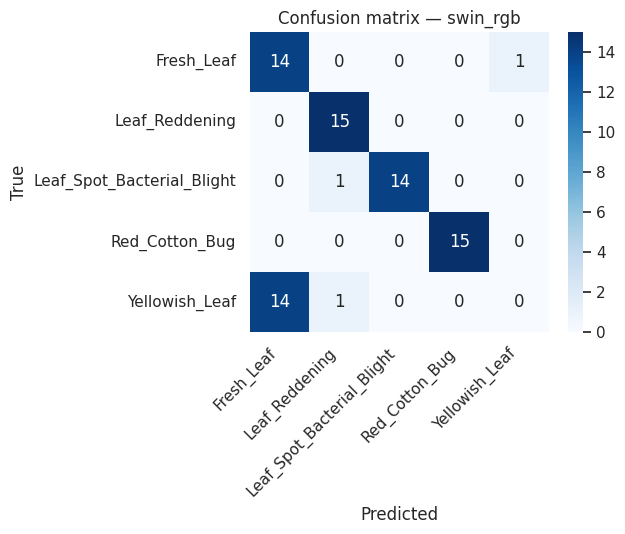


Experiment: swin_hog  (mode=stack, channels=['hog'])
[swin_hog] epoch 01/30 train_loss=0.5938 train_acc=0.9211 val_loss=1.1278 val_acc=0.7568 val_macroF1=0.6777 (68.2s)
[swin_hog] epoch 02/30 train_loss=0.4978 train_acc=0.9685 val_loss=0.9832 val_acc=0.7297 val_macroF1=0.6549 (65.5s)
[swin_hog] epoch 03/30 train_loss=0.4833 train_acc=0.9720 val_loss=1.1025 val_acc=0.7432 val_macroF1=0.6673 (67.0s)
[swin_hog] epoch 04/30 train_loss=0.5001 train_acc=0.9637 val_loss=1.2441 val_acc=0.7162 val_macroF1=0.6355 (70.7s)
[swin_hog] epoch 05/30 train_loss=0.4646 train_acc=0.9818 val_loss=1.2163 val_acc=0.7027 val_macroF1=0.6262 (70.0s)
[swin_hog] epoch 06/30 train_loss=0.4506 train_acc=0.9872 val_loss=0.9476 val_acc=0.7568 val_macroF1=0.6944 (69.0s)
[swin_hog] epoch 07/30 train_loss=0.4534 train_acc=0.9899 val_loss=0.8079 val_acc=0.8243 val_macroF1=0.7881 (68.1s)
[swin_hog] epoch 08/30 train_loss=0.4401 train_acc=0.9935 val_loss=1.0816 val_acc=0.7432 val_macroF1=0.6638 (67.3s)
[swin_hog] epoch 0

=== Classification report: swin_hog ===
                            precision    recall  f1-score   support

                Fresh_Leaf     0.5769    1.0000    0.7317        15
            Leaf_Reddening     0.9333    0.9333    0.9333        15
Leaf_Spot_Bacterial_Blight     0.8824    1.0000    0.9375        15
            Red_Cotton_Bug     1.0000    1.0000    1.0000        15
            Yellowish_Leaf     1.0000    0.1333    0.2353        15

                  accuracy                         0.8133        75
                 macro avg     0.8785    0.8133    0.7676        75
              weighted avg     0.8785    0.8133    0.7676        75



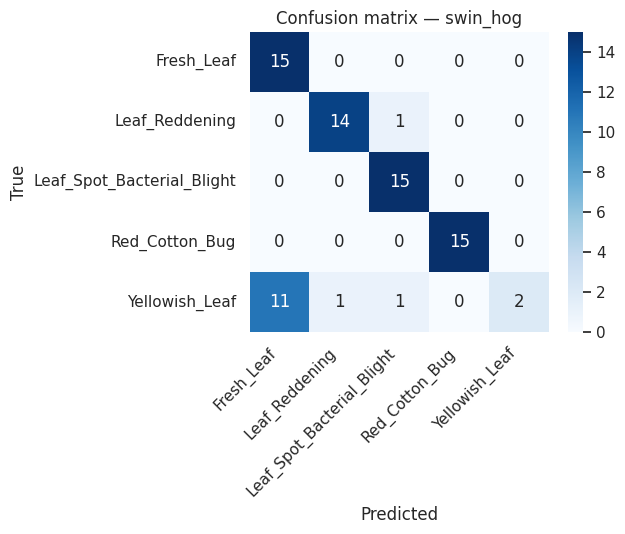


Experiment: swin_wavelet  (mode=stack, channels=['wavelet'])
[swin_wavelet] epoch 01/30 train_loss=0.5963 train_acc=0.9214 val_loss=1.0943 val_acc=0.7432 val_macroF1=0.6638 (24.2s)
[swin_wavelet] epoch 02/30 train_loss=0.4931 train_acc=0.9702 val_loss=0.8943 val_acc=0.7568 val_macroF1=0.7212 (24.0s)
[swin_wavelet] epoch 03/30 train_loss=0.4882 train_acc=0.9711 val_loss=0.8157 val_acc=0.8514 val_macroF1=0.8448 (23.9s)
[swin_wavelet] epoch 04/30 train_loss=0.4870 train_acc=0.9714 val_loss=1.1150 val_acc=0.7432 val_macroF1=0.6842 (24.0s)
[swin_wavelet] epoch 05/30 train_loss=0.4715 train_acc=0.9786 val_loss=1.2844 val_acc=0.7162 val_macroF1=0.6355 (24.0s)
[swin_wavelet] epoch 06/30 train_loss=0.4753 train_acc=0.9777 val_loss=0.8736 val_acc=0.7568 val_macroF1=0.6930 (24.0s)
[swin_wavelet] epoch 07/30 train_loss=0.4620 train_acc=0.9821 val_loss=0.8023 val_acc=0.7838 val_macroF1=0.7484 (23.9s)
[swin_wavelet] epoch 08/30 train_loss=0.4579 train_acc=0.9848 val_loss=1.0134 val_acc=0.7162 val_m

=== Classification report: swin_wavelet ===
                            precision    recall  f1-score   support

                Fresh_Leaf     0.5909    0.8667    0.7027        15
            Leaf_Reddening     0.9375    1.0000    0.9677        15
Leaf_Spot_Bacterial_Blight     0.8333    1.0000    0.9091        15
            Red_Cotton_Bug     1.0000    1.0000    1.0000        15
            Yellowish_Leaf     1.0000    0.2667    0.4211        15

                  accuracy                         0.8267        75
                 macro avg     0.8723    0.8267    0.8001        75
              weighted avg     0.8723    0.8267    0.8001        75



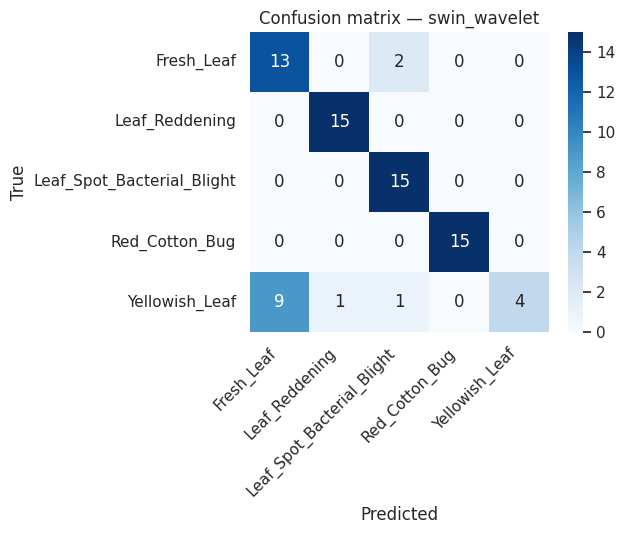


Experiment: swin_hog_wavelet  (mode=stack, channels=['hog', 'wavelet'])
[swin_hog_wavelet] epoch 01/30 train_loss=0.5950 train_acc=0.9211 val_loss=0.9918 val_acc=0.7297 val_macroF1=0.6658 (68.0s)
[swin_hog_wavelet] epoch 02/30 train_loss=0.5022 train_acc=0.9690 val_loss=0.9232 val_acc=0.7568 val_macroF1=0.6763 (68.4s)
[swin_hog_wavelet] epoch 03/30 train_loss=0.5134 train_acc=0.9601 val_loss=0.9910 val_acc=0.7432 val_macroF1=0.6624 (69.3s)
[swin_hog_wavelet] epoch 04/30 train_loss=0.4622 train_acc=0.9821 val_loss=0.9331 val_acc=0.7162 val_macroF1=0.6721 (67.9s)
[swin_hog_wavelet] epoch 05/30 train_loss=0.4757 train_acc=0.9765 val_loss=1.1715 val_acc=0.6892 val_macroF1=0.6019 (69.9s)
[swin_hog_wavelet] epoch 06/30 train_loss=0.4618 train_acc=0.9833 val_loss=1.0234 val_acc=0.7838 val_macroF1=0.7222 (69.1s)
[swin_hog_wavelet] epoch 07/30 train_loss=0.4471 train_acc=0.9920 val_loss=0.8314 val_acc=0.8108 val_macroF1=0.7590 (70.0s)
[swin_hog_wavelet] epoch 08/30 train_loss=0.4359 train_acc=

=== Classification report: swin_hog_wavelet ===
                            precision    recall  f1-score   support

                Fresh_Leaf     0.5769    1.0000    0.7317        15
            Leaf_Reddening     0.9375    1.0000    0.9677        15
Leaf_Spot_Bacterial_Blight     0.9375    1.0000    0.9677        15
            Red_Cotton_Bug     1.0000    1.0000    1.0000        15
            Yellowish_Leaf     1.0000    0.1333    0.2353        15

                  accuracy                         0.8267        75
                 macro avg     0.8904    0.8267    0.7805        75
              weighted avg     0.8904    0.8267    0.7805        75



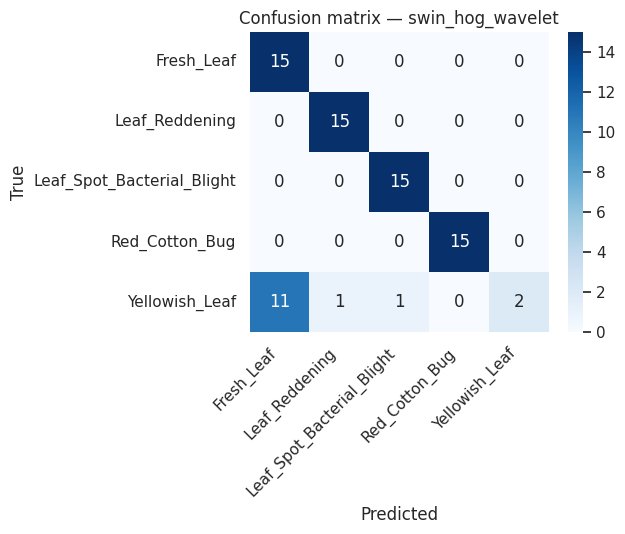


Experiment: swin_hog_only  (mode=tile, channels=hog)
[swin_hog_only] epoch 01/30 train_loss=1.4835 train_acc=0.3932 val_loss=1.4327 val_acc=0.4595 val_macroF1=0.4264 (65.0s)
[swin_hog_only] epoch 02/30 train_loss=1.1250 train_acc=0.6690 val_loss=1.4702 val_acc=0.5541 val_macroF1=0.4945 (64.7s)
[swin_hog_only] epoch 03/30 train_loss=0.9366 train_acc=0.7765 val_loss=1.3042 val_acc=0.5811 val_macroF1=0.5443 (64.1s)
[swin_hog_only] epoch 04/30 train_loss=0.8335 train_acc=0.8220 val_loss=1.3389 val_acc=0.5946 val_macroF1=0.5484 (64.5s)
[swin_hog_only] epoch 05/30 train_loss=0.7954 train_acc=0.8321 val_loss=1.2513 val_acc=0.5946 val_macroF1=0.5194 (63.2s)
[swin_hog_only] epoch 06/30 train_loss=0.7686 train_acc=0.8405 val_loss=1.3978 val_acc=0.5946 val_macroF1=0.5242 (64.2s)
[swin_hog_only] epoch 07/30 train_loss=0.7200 train_acc=0.8682 val_loss=1.3276 val_acc=0.5946 val_macroF1=0.5128 (64.0s)
[swin_hog_only] epoch 08/30 train_loss=0.7122 train_acc=0.8682 val_loss=1.2817 val_acc=0.6486 val_m

=== Classification report: swin_hog_only ===
                            precision    recall  f1-score   support

                Fresh_Leaf     0.5217    0.8000    0.6316        15
            Leaf_Reddening     0.6000    0.2000    0.3000        15
Leaf_Spot_Bacterial_Blight     0.4828    0.9333    0.6364        15
            Red_Cotton_Bug     1.0000    0.9333    0.9655        15
            Yellowish_Leaf     0.5000    0.1333    0.2105        15

                  accuracy                         0.6000        75
                 macro avg     0.6209    0.6000    0.5488        75
              weighted avg     0.6209    0.6000    0.5488        75



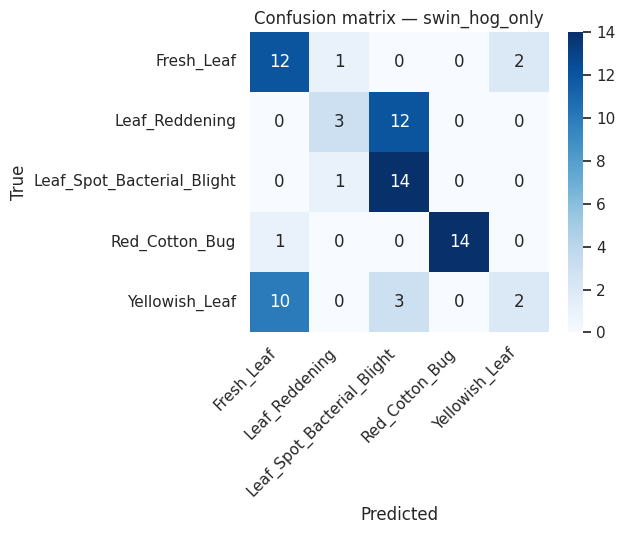


Experiment: swin_wavelet_only  (mode=tile, channels=wavelet)
[swin_wavelet_only] epoch 01/30 train_loss=0.7176 train_acc=0.8735 val_loss=1.2088 val_acc=0.6892 val_macroF1=0.6294 (23.8s)
[swin_wavelet_only] epoch 02/30 train_loss=0.5733 train_acc=0.9363 val_loss=1.0761 val_acc=0.7568 val_macroF1=0.6838 (23.7s)
[swin_wavelet_only] epoch 03/30 train_loss=0.5466 train_acc=0.9455 val_loss=1.1580 val_acc=0.6486 val_macroF1=0.5459 (23.5s)
[swin_wavelet_only] epoch 04/30 train_loss=0.5185 train_acc=0.9551 val_loss=1.0928 val_acc=0.6892 val_macroF1=0.6018 (23.7s)
[swin_wavelet_only] epoch 05/30 train_loss=0.5084 train_acc=0.9610 val_loss=1.2436 val_acc=0.6486 val_macroF1=0.5482 (23.7s)
[swin_wavelet_only] epoch 06/30 train_loss=0.4989 train_acc=0.9658 val_loss=1.1242 val_acc=0.7703 val_macroF1=0.7018 (23.6s)
[swin_wavelet_only] epoch 07/30 train_loss=0.5185 train_acc=0.9595 val_loss=1.2571 val_acc=0.6757 val_macroF1=0.5968 (23.6s)
[swin_wavelet_only] epoch 08/30 train_loss=0.4669 train_acc=0.9

=== Classification report: swin_wavelet_only ===
                            precision    recall  f1-score   support

                Fresh_Leaf     0.4839    1.0000    0.6522        15
            Leaf_Reddening     1.0000    0.4000    0.5714        15
Leaf_Spot_Bacterial_Blight     0.6522    1.0000    0.7895        15
            Red_Cotton_Bug     1.0000    1.0000    1.0000        15
            Yellowish_Leaf     0.0000    0.0000    0.0000        15

                  accuracy                         0.6800        75
                 macro avg     0.6272    0.6800    0.6026        75
              weighted avg     0.6272    0.6800    0.6026        75



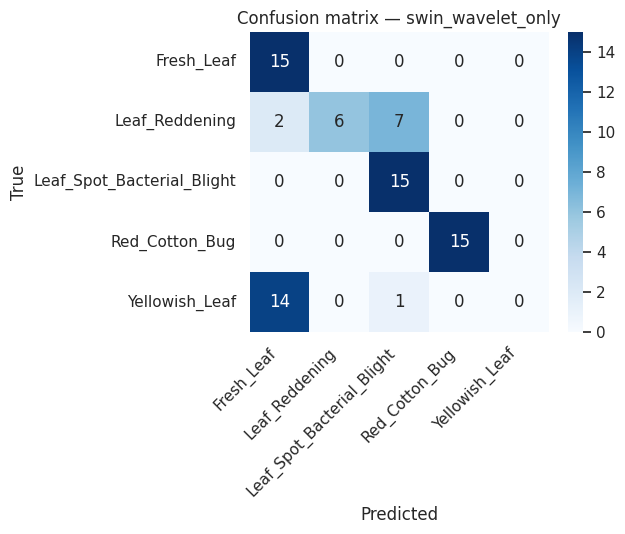


All six experiments complete.


In [15]:
# Cell 15 — Train, plot, and evaluate EACH model in full (run this cell once per experiment,
# or run straight through for all six in one pass)
for tag, cfg in MODEL_CONFIGS.items():
    mode = cfg["mode"]
    channel_spec = cfg["channels"]
    num_extra_channels = len(channel_spec) if mode == "stack" else 0   # tile mode stays 3ch total

    print(f"\n{'='*70}\nExperiment: {tag}  (mode={mode}, channels={channel_spec})\n{'='*70}")

    train_ds = ChannelDataset(train_df, channel_spec, mode=mode)
    val_ds   = ChannelDataset(val_df, channel_spec, mode=mode)
    test_ds  = ChannelDataset(test_df, channel_spec, mode=mode)

    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=CONFIG["num_workers"], drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                               num_workers=CONFIG["num_workers"])
    test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                               num_workers=CONFIG["num_workers"])

    set_seed(CONFIG["seed"])   # identical init conditions across models, isolating the architecture effect
    model = build_swin(num_extra_channels, NUM_CLASSES, pretrained=True)
    model, history = train_model(model, train_loader, val_loader, CONFIG, tag=tag)
    histories[tag] = history
    trained_models[tag] = model

    plot_curves(history, tag)
    test_metrics, test_preds, test_labels = evaluate(model, test_loader, tag)

    torch.save(model.state_dict(), Path(CONFIG["model_dir"], f"{tag}_best.pth"))

    row = {"experiment_id": tag, "mode": mode, "input_channels": 3 + num_extra_channels,
           "epochs": CONFIG["epochs"], **test_metrics}
    results_rows.append(row)
    pd.DataFrame([row]).to_csv(CONFIG["results_csv"], mode="a",
                                header=not Path(CONFIG["results_csv"]).exists(), index=False)

print("\nAll six experiments complete.")


## 7. Cross-model comparison

In [16]:
# Cell 16 — Comparison table and bar charts across all four models
results_df = pd.DataFrame(results_rows)
print(results_df[["experiment_id", "input_channels", "accuracy", "macro_f1",
                   "yellowish_recall", "yellowish_f1"]].sort_values("macro_f1", ascending=False))

fig = go.Figure()
fig.add_trace(go.Bar(x=results_df["experiment_id"], y=results_df["accuracy"]*100, name="Accuracy (%)"))
fig.add_trace(go.Bar(x=results_df["experiment_id"], y=results_df["macro_f1"]*100, name="Macro F1 (x100)"))
fig.update_layout(title="Overall accuracy and macro-F1 across early-fusion variants",
                   template="plotly_white", barmode="group", width=1000, height=550,
                   xaxis_title="Model", yaxis_title="Score")
fig.show()

fig2 = go.Figure()
fig2.add_trace(go.Bar(x=results_df["experiment_id"], y=results_df["yellowish_recall"]*100, name="Yellowish_Leaf recall (%)"))
fig2.update_layout(title="Yellowish_Leaf recall — the project's consistently hardest class",
                    template="plotly_white", width=1000, height=550,
                    xaxis_title="Model", yaxis_title="Recall (%)")
fig2.show()


       experiment_id  input_channels  accuracy  macro_f1  yellowish_recall  \
2       swin_wavelet               4  0.826667  0.800118          0.266667   
3   swin_hog_wavelet               5  0.826667  0.780497          0.133333   
1           swin_hog               4  0.813333  0.767567          0.133333   
0           swin_rgb               3  0.773333  0.710836          0.000000   
5  swin_wavelet_only               3  0.680000  0.602615          0.000000   
4      swin_hog_only               3  0.600000  0.548797          0.133333   

   yellowish_f1  
2      0.421053  
3      0.235294  
1      0.235294  
0      0.000000  
5      0.000000  
4      0.210526  


In [17]:
# Cell 17 — Overlay all four models' val loss and val accuracy curves on one chart each
fig = go.Figure()
for tag, h in histories.items():
    epochs = list(range(1, len(h["val_loss"]) + 1))
    fig.add_trace(go.Scatter(x=epochs, y=h["val_loss"], mode="lines", name=tag))
fig.update_layout(title="Validation loss — all early-fusion models", template="plotly_white",
                   width=1000, height=550, xaxis_title="Epoch", yaxis_title="Validation loss")
fig.show()

fig2 = go.Figure()
for tag, h in histories.items():
    epochs = list(range(1, len(h["val_acc"]) + 1))
    fig2.add_trace(go.Scatter(x=epochs, y=[a*100 for a in h["val_acc"]], mode="lines", name=tag))
fig2.update_layout(title="Validation accuracy — all early-fusion models", template="plotly_white",
                    width=1000, height=550, xaxis_title="Epoch", yaxis_title="Validation accuracy (%)")
fig2.show()


## 8. Save artifacts for future weather-data fusion

Each model's pooled pre-classification embedding is extracted and saved, keyed to
`image_id -> embedding -> label`, matching the convention used throughout this project so
a later notebook can join on capture date and fuse with a weather encoder.


In [18]:
# Cell 18 — Export pooled embeddings for the winning model (edit BEST_TAG once results are in)
BEST_TAG = results_df.loc[results_df["macro_f1"].idxmax(), "experiment_id"]
print("Best model by macro-F1:", BEST_TAG)

best_model = trained_models[BEST_TAG].to(CONFIG["device"]).eval()
best_cfg = MODEL_CONFIGS[BEST_TAG]
best_mode = best_cfg["mode"]
best_channels = best_cfg["channels"]
best_num_extra = len(best_channels) if best_mode == "stack" else 0

@torch.no_grad()
def extract_embedding(model, df, channel_spec, mode):
    ds = ChannelDataset(df, channel_spec, mode=mode)
    loader = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
    feats, labels = [], []
    orig_head = model.head
    model.head = nn.Identity()
    for xb, yb in loader:
        out = model(xb.to(CONFIG["device"]))
        feats.append(out.cpu().numpy())
        labels.append(yb.numpy())
    model.head = orig_head
    return np.concatenate(feats), np.concatenate(labels)

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    feats, labels = extract_embedding(best_model, df, best_channels, best_mode)
    np.savez_compressed(
        Path(CONFIG["feature_dir"], f"{BEST_TAG}_{split_name}_embeddings.npz"),
        features=feats, labels=labels, paths=df["path"].values,
    )
    print(f"{split_name}: saved {feats.shape} embeddings for {BEST_TAG}")

metadata = {
    "best_model": BEST_TAG, "input_channels": 3 + best_num_extra,
    "num_classes": NUM_CLASSES, "class_names": class_names,
    "image_size": CONFIG["image_size"], "epochs": CONFIG["epochs"],
    "results_summary": results_df.to_dict(orient="records"),
}
with open(Path(CONFIG["feature_dir"], "early_fusion_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved early_fusion_metadata.json")


Best model by macro-F1: swin_wavelet
train: saved (3371, 768) embeddings for swin_wavelet
val: saved (74, 768) embeddings for swin_wavelet
test: saved (75, 768) embeddings for swin_wavelet
Saved early_fusion_metadata.json


## 9. Interpretation notes for the thesis write-up

- If `swin_hog_wavelet` (or any channel-extended variant) beats `swin_rgb`, that is direct
  evidence handcrafted spatial priors help Swin's own representation learning — a claim
  the *late*-fusion experiment in the companion notebook could not make, since there Swin
  never saw the handcrafted signal at all.
- If it does *not* beat `swin_rgb`, that is still a legitimate, reportable finding: it would
  indicate the averaged-channel initialization is not a strong enough starting point for
  the added channels to be learned usefully within 30 epochs on a ~3,600-image dataset —
  a concrete, citable limitation (channel-extension methods in the literature above were
  generally validated on larger datasets or with longer fine-tuning schedules).
- Check `Yellowish_Leaf` recall specifically across all four models before drawing an
  overall conclusion — per every prior experiment in this project, that class is the one
  most likely to reveal whether a change is a genuine architectural improvement or a shift
  that only helps the already-easy classes.
